# Frequency domain examples

Example code which computes eigenvalues and eigenvectors of linearized radial perturbations of perfect and Eckart fluid stars.

In [ ]:
include("../params.jl");

Star(5.5e15, 0.004084389065951561, 0.0016682234042064664, 100.0, 1.0, NeutronStarOscillations.var"#EOS_ε#2"{Float64, Float64}(100.0, 2.0), NeutronStarOscillations.var"#EOS_p#3"{Float64, Float64}(100.0, 2.0), NeutronStarOscillations.var"#dp_dε#4"{Float64, Float64}(100.0, 2.0), NeutronStarOscillations.var"#d2p_dε2#5"{Float64, Float64}(100.0, 2.0), 0.01, 0.01, 15.0, 1.5, 20.0, 1.0, 1.6682234042064662e-9, 1.6682234042064664e-6, "./Results/Data/", "./Results/Figures/", 1.0e-15, 10, 100000000000, 1.0e-15, 1.0e-12, 1.0e-12, 200, 5, Main.xi_ID, Main.xi_dt_ID, Main.du_ID, Main.du_dr_ID, Main.du_dt_ID, Main.de_ID, Main.de_dr_ID, Main.de_dt_ID, 0.2, 0.1, 0.0005, 0.04, 50, 0.05, -1)

In [2]:
nPointsMatrix = 500;
h1_shoot = 4e-2;
h2_shoot = h1_shoot / 2;
h3_shoot = h1_shoot / 4;
h_TOV = 1e-5;

## Perfect fluid star in the cowling approximation

In [3]:
cowling = true;

In [4]:
@time compute_eigensystem(PF_star, h1_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);
@time compute_eigensystem(PF_star, h2_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);
@time compute_eigensystem(PF_star, h3_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);

Computing perfect fluid Cowling eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
 17.315574 seconds (94.63 M allocations: 3.394 GiB, 14.28% gc time, 104.05% compilation time: 3% of which was recompilation)
Computing perfect fluid Cowling eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
 17.197675 seconds (107.16 M allocations: 3.650 GiB, 15.10% gc time, 79.63% compilation time)
Computing perfect fluid Cowling eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
 19.870156 seconds (135.83 M allocations: 4.252 GiB, 11.73% gc time, 83.20% compilation time)


In [5]:
# load eigensystems. Eigenvalues are linear frequencies squared, i.e., ν^2 where ν = ω / (2π) and [ν] = kHz
init_freqs_1, shooting_freqs_1, radii_1, evecs_1, resids_1, ret_1 = load_eigensystem(PF_star, h1_shoot, cowling);
init_freqs_2, shooting_freqs_2, radii_2, evecs_2, resids_2, ret_2 = load_eigensystem(PF_star, h2_shoot, cowling);
init_freqs_3, shooting_freqs_3, radii_3, evecs_3, resids_3, ret_3 = load_eigensystem(PF_star, h3_shoot, cowling);

In [6]:
# check convergence
diff_12 = abs.(shooting_freqs_1 .- shooting_freqs_2)
diff_23 = abs.(shooting_freqs_2 .- shooting_freqs_3)
prod(@. ((diff_23 < diff_12) || diff_23 == diff_12 == 0.0)) ? println("FREQUENCIES CONVERGING") : println("FREQUENCIES NOT CONVERGING")

FREQUENCIES CONVERGING


In [7]:
# linear frequencies in kHz (if the equilibrium configuration is unstable, then the squared frequencies will be negative and the code below will throw an error due to the sqrt)
freqs_1 = sqrt.(shooting_freqs_1);
freqs_2 = sqrt.(shooting_freqs_2);
freqs_3 = sqrt.(shooting_freqs_3);

In [8]:
# print return codes for the shooting method iterations
println("*** NonlinearSolve return codes for shooting method ***")
println("(Low res) PF shooting method return codes: ", ret_1)
println("(Med res) PF shooting method return codes: ", ret_2)
println("(High res) PF shooting method return codes: ", ret_3)

# print highest resolution frequencies
println("*** Linear frequencies ν = ω / 2π, [v] = κHz ***")
println("(Low res) PF fluid frequencies (kHz): ", freqs_1)
println("(Med res) PF fluid frequencies (kHz): ", freqs_2)
println("(High res) PF fluid frequencies (kHz): ", freqs_3)

*** NonlinearSolve return codes for shooting method ***
(Low res) PF shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
(Med res) PF shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
(High res) PF shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
*** Linear frequencies ν = ω / 2π, [v] = κHz ***
(Low res) PF fluid frequencies (kHz): [5.512697333317798, 9.138696267797592, 12.686455327867112, 16.250055843399537, 19.84282698851267]
(Med res) PF fluid frequencies (kHz): [5.504903089969704, 9.10467277793815, 12.596610362419378, 16.073449337993665, 19.55478545279021]
(High res) PF fluid frequencies (kHz): [5.504850760945346, 9.10443864337666, 12.59597908533719, 16.072207262153526, 19.552832114663445]


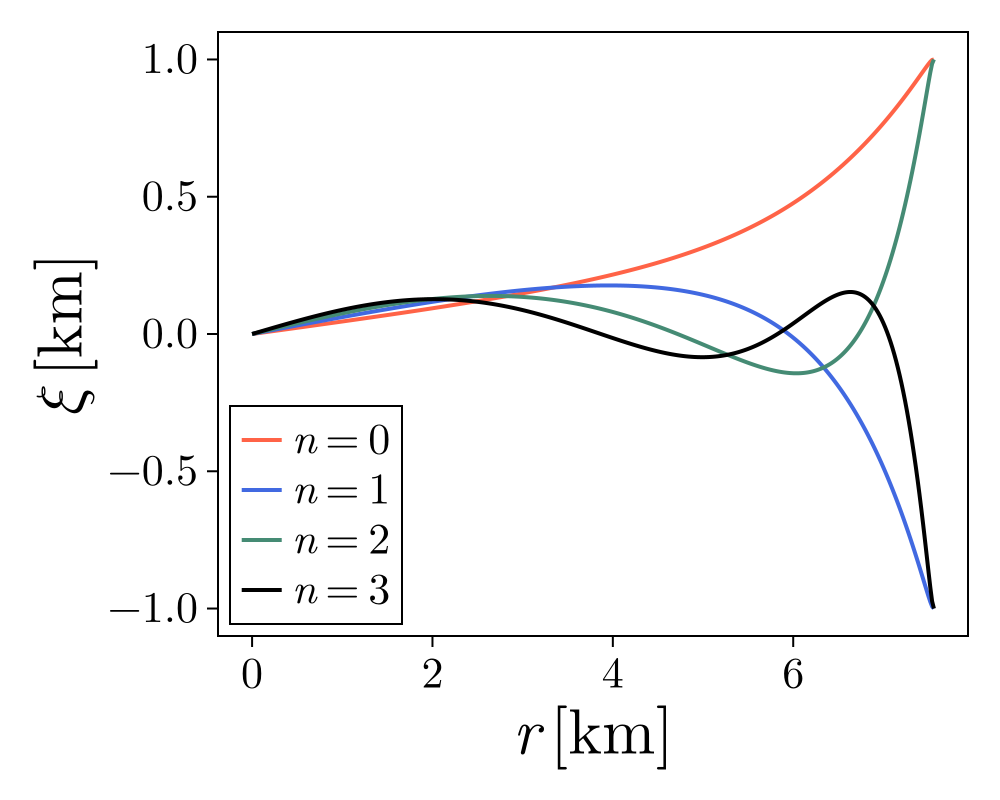

In [9]:
# plot eigenvectors
modes = [0, 1, 2, 3];
method = "Shoot Cowling";
xlabel = L"r\,[\mathrm{km}]";
ylabel = L"\xi\,[\mathrm{km}]";
legend = true;
labels = [L"n=%$mode" for mode in modes];
framevisible = true;

plot_fd_eigvecs(
    modes, PF_star, method; h=h3_shoot,
    xlabel = xlabel,
    ylabel = ylabel,
    legend = legend,
    labels = labels,
    position = :lb,
    framevisible = framevisible
);

## Perfect fluid star

In [10]:
cowling = false;

In [11]:
@time compute_eigensystem(PF_star, h1_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);
@time compute_eigensystem(PF_star, h2_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);
@time compute_eigensystem(PF_star, h3_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);

Computing perfect fluid eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
 12.302854 seconds (92.89 M allocations: 3.352 GiB, 17.56% gc time, 87.80% compilation time)
Computing perfect fluid eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
 16.664103 seconds (106.65 M allocations: 3.677 GiB, 14.51% gc time, 80.91% compilation time)
Computing perfect fluid eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
 19.645719 seconds (134.75 M allocations: 4.135 GiB, 10.70% gc time, 88.61% compilation time)


In [12]:
# load eigensystems. Eigenvalues are linear frequencies squared, i.e., ν^2 where ν = ω / (2π) and [ν] = kHz
init_freqs_1, shooting_freqs_1, radii_1, evecs_1, resids_1, ret_1 = load_eigensystem(PF_star, h1_shoot, cowling);
init_freqs_2, shooting_freqs_2, radii_2, evecs_2, resids_2, ret_2 = load_eigensystem(PF_star, h2_shoot, cowling);
init_freqs_3, shooting_freqs_3, radii_3, evecs_3, resids_3, ret_3 = load_eigensystem(PF_star, h3_shoot, cowling);

In [13]:
# check convergence
diff_12 = abs.(shooting_freqs_1 .- shooting_freqs_2)
diff_23 = abs.(shooting_freqs_2 .- shooting_freqs_3)
prod(@. ((diff_23 < diff_12) || diff_23 == diff_12 == 0.0)) ? println("FREQUENCIES CONVERGING") : println("FREQUENCIES NOT CONVERGING")

FREQUENCIES CONVERGING


In [14]:
# linear frequencies in kHz (if the equilibrium configuration is unstable, then the squared frequencies will be negative and the code below will throw an error due to the sqrt)
freqs_1 = sqrt.(shooting_freqs_1);
freqs_2 = sqrt.(shooting_freqs_2);
freqs_3 = sqrt.(shooting_freqs_3);

In [15]:
# print return codes for the shooting method iterations
println("*** NonlinearSolve return codes for shooting method ***")
println("(Low res) PF shooting method return codes: ", ret_1)
println("(Med res) PF shooting method return codes: ", ret_2)
println("(High res) PF shooting method return codes: ", ret_3)

# print highest resolution frequencies
println("*** Linear frequencies ν = ω / 2π, [v] = κHz ***")
println("(Low res) PF fluid frequencies (kHz): ", freqs_1)
println("(Med res) PF fluid frequencies (kHz): ", freqs_2)
println("(High res) PF fluid frequencies (kHz): ", freqs_3)

*** NonlinearSolve return codes for shooting method ***
(Low res) PF shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
(Med res) PF shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
(High res) PF shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
*** Linear frequencies ν = ω / 2π, [v] = κHz ***
(Low res) PF fluid frequencies (kHz): [0.5728046179879316, 7.576141587536057, 11.599944442218144, 15.406455563938433, 19.15052922714718]
(Med res) PF fluid frequencies (kHz): [0.5615882867125257, 7.553083562664036, 11.524262307663468, 15.244608079131142, 18.875985063747784]
(High res) PF fluid frequencies (kHz): [0.5615141446090189, 7.552927251277525, 11.523734820121003, 15.243469838353242, 18.874107106095703]


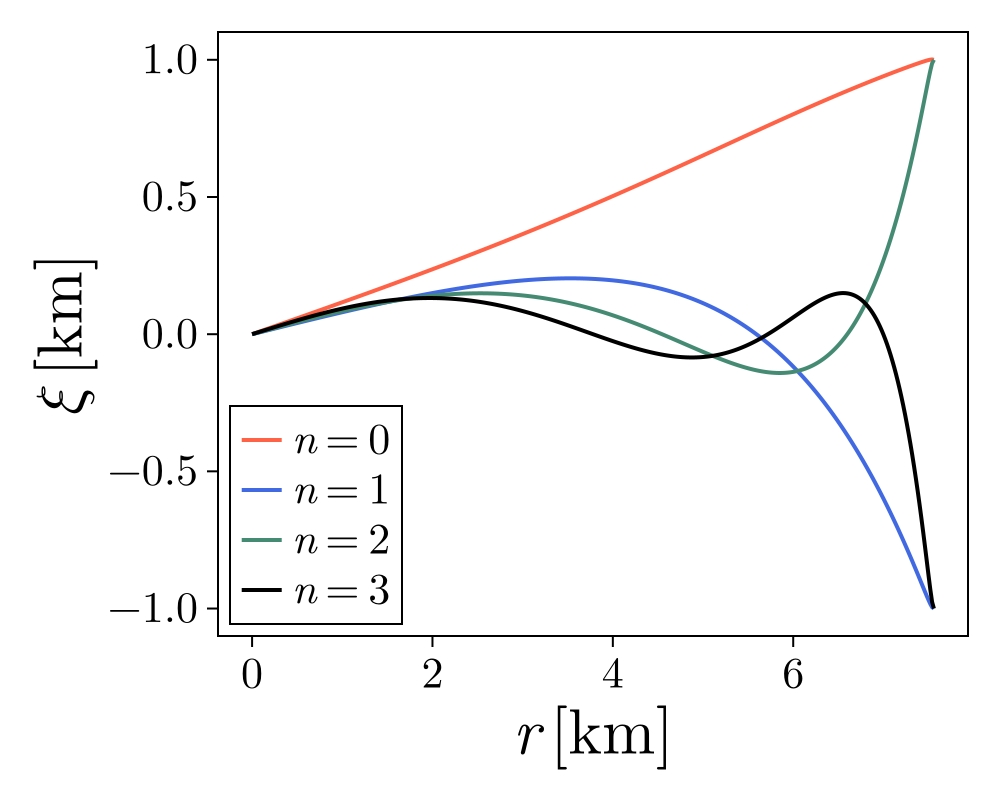

In [16]:
# plot eigenvectors
modes = [0, 1, 2, 3];
method = "Shoot";
xlabel = L"r\,[\mathrm{km}]";
ylabel = L"\xi\,[\mathrm{km}]";
legend = true;
labels = [L"n=%$mode" for mode in modes];
framevisible = true;

plot_fd_eigvecs(
    modes, PF_star, method; h=h3_shoot,
    xlabel = xlabel,
    ylabel = ylabel,
    legend = legend,
    labels = labels,
    position = :lb,
    framevisible = framevisible
);

## Eckart star

In [17]:
cowling = false;

In [18]:
@time compute_eigensystem(Eckart_star, h1_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);
@time compute_eigensystem(Eckart_star, h2_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);
@time compute_eigensystem(Eckart_star, h3_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);

Computing Eckart fluid eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
 19.340973 seconds (81.99 M allocations: 3.178 GiB, 11.14% gc time, 94.51% compilation time)
Computing Eckart fluid eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
 18.266831 seconds (82.06 M allocations: 3.197 GiB, 11.30% gc time, 85.59% compilation time)
Computing Eckart fluid eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
 16.074514 seconds (81.21 M allocations: 3.095 GiB, 8.21% gc time, 95.86% compilation time)


In [19]:
# load eigensystems. Eigenvalues are (complex-valued) linear frequencies, i.e., ν = ω / (2π) and [ν] = kHz
init_freqs_1, shooting_freqs_1, radii_1, evecs_1, resids_1, ret_1 = load_eigensystem(Eckart_star, h1_shoot, cowling);
init_freqs_2, shooting_freqs_2, radii_2, evecs_2, resids_2, ret_2 = load_eigensystem(Eckart_star, h2_shoot, cowling);
init_freqs_3, shooting_freqs_3, radii_3, evecs_3, resids_3, ret_3 = load_eigensystem(Eckart_star, h3_shoot, cowling);


In [20]:
# check convergence
diff_12 = abs.(shooting_freqs_1 .- shooting_freqs_2)
diff_23 = abs.(shooting_freqs_2 .- shooting_freqs_3)
prod(@. ((diff_23 < diff_12) || diff_23 == diff_12 == 0.0)) ? println("FREQUENCIES CONVERGING") : println("FREQUENCIES NOT CONVERGING")

FREQUENCIES CONVERGING


In [21]:
# print return codes for the shooting method iterations
println("*** NonlinearSolve return codes for shooting method ***")
println("(Low res) Eckart shooting method return codes: ", ret_1)
println("(Med res) Eckart shooting method return codes: ", ret_2)
println("(High res) Eckart shooting method return codes: ", ret_3)

# print highest resolution frequencies
println("*** Linear frequencies ν = ω / 2π, [v] = κHz ***")
println("(Low res) Eckart fluid frequencies (kHz): ", shooting_freqs_1)
println("(Med res) Eckart fluid frequencies (kHz): ", shooting_freqs_2)
println("(High res) Eckart fluid frequencies (kHz): ", shooting_freqs_3)

*** NonlinearSolve return codes for shooting method ***
(Low res) Eckart shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
(Med res) Eckart shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
(High res) Eckart shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
*** Linear frequencies ν = ω / 2π, [v] = κHz ***
(Low res) Eckart fluid frequencies (kHz): ComplexF64[0.572763848351077 - 0.0076473797818237465im, 7.576082313796083 - 0.033117011006929944im, 11.599770575787296 - 0.07024803991401851im, 15.406073161113788 - 0.12013584141414574im, 19.1498096973678 - 0.18320724476282568im]
(Med res) Eckart fluid frequencies (kHz): ComplexF64[0.5615371205787844 - 0.007636174066999969im, 7.553025228759606 - 0.03285608174671977im, 11.524094040997685 - 0.06902805984066243im, 15.244243787773172 - 0.11682785178846158im, 18.87531310547078 - 0.17648840749871422im]
(High res) Eckart fluid frequencies (kHz)

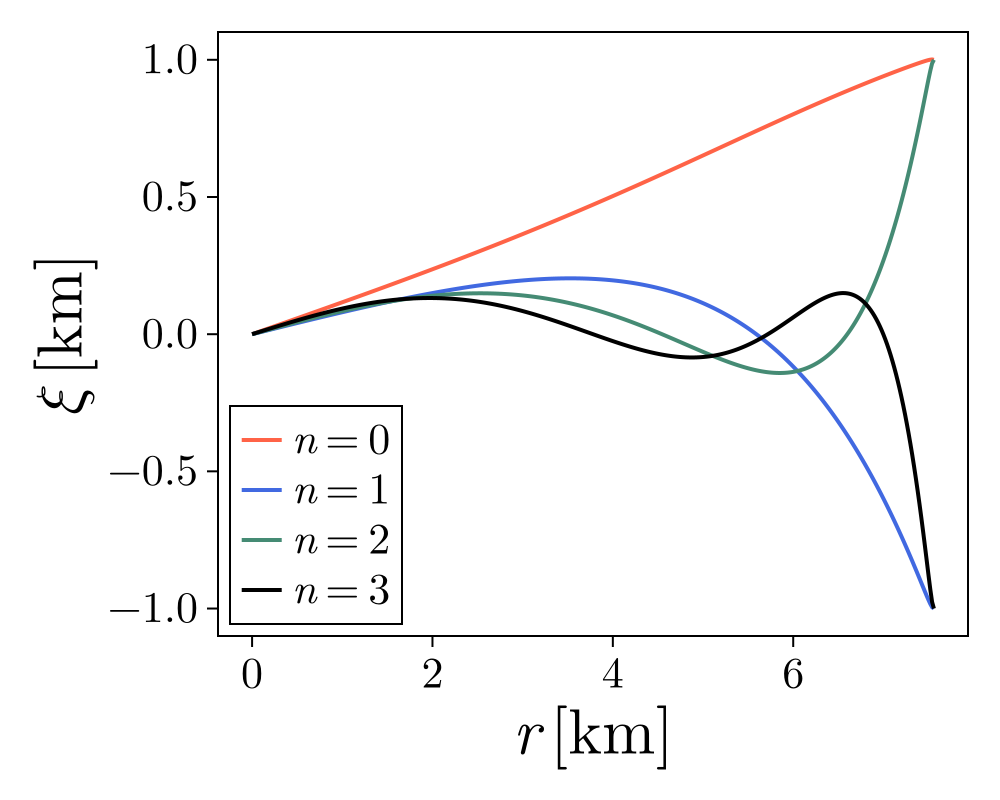

In [22]:
# plot eigenvectors
modes = [0, 1, 2, 3];
method = "Shoot";
xlabel = L"r\,[\mathrm{km}]";
ylabel = L"\xi\,[\mathrm{km}]";
legend = true;
labels = [L"n=%$mode" for mode in modes];
framevisible = true;

plot_fd_eigvecs(
    modes, Eckart_star, method; h=h3_shoot,
    xlabel = xlabel,
    ylabel = ylabel,
    legend = legend,
    labels = labels,
    position = :lb,
    framevisible = framevisible
);